# Deep Reinforcement Learning for Equity Trading: A Rainbow-DQN Study

**A reproducible end-to-end pipeline with realistic frictions, multi-seed evaluation, and walk-forward backtesting.**

---

## Abstract

We investigate the practical efficacy of Deep Q-Networks (DQN) and its modern descendants, Double DQN, Dueling DQN, Prioritized Experience Replay, N-step returns, Noisy Networks, and Distributional (C51), for single-asset equity trading. We extend the canonical DQN-trading setup with three contributions absent from prior coursework: (i) realistic transaction frictions (commission and slippage) directly in the reward signal; (ii) a strict chronological train/validation/test split combined with five-fold walk-forward backtesting; and (iii) a multi-seed evaluation that quantifies estimator variance using equity-curve confidence bands. We benchmark against four non-RL baselines (buy-and-hold, SMA crossover, RSI mean-reversion, and a stochastic strategy) and report risk-adjusted metrics (Sharpe, Sortino, Calmar, max drawdown). On Apple Inc. (AAPL) over 2018, 2024, the Double-Dueling agent achieves a median walk-forward Sharpe of approximately 1.5 across folds, comparable to the buy-and-hold baseline once frictions are imposed. Rainbow agents do not consistently outperform simpler variants, indicating diminishing returns from architectural complexity in noisy, non-stationary financial environments. The pipeline is open-source, modular, and ships with a Streamlit dashboard, Optuna tuner, and TensorBoard logging.

---

## 1. Introduction

Reinforcement learning (RL) has produced superhuman policies in games (Mnih et al., 2015; Silver et al., 2016) and has attracted substantial attention as a candidate for sequential decision-making in finance. Stock trading is naturally cast as a Markov Decision Process: an agent observes market state, selects an action (buy/sell/hold or fractional weight), and receives a reward (portfolio change). Unlike Atari, however, financial environments are non-stationary, partially observable, low-signal-to-noise, and adversarial. These properties violate core RL assumptions and have hampered consistent published results.

This work re-implements and extends a previously published student pipeline (ST455 coursework, May 2024) that applied vanilla DQN to AAPL daily returns. The original pipeline contained three latent defects: (a) an unbounded cumulative reward that artificially inflated training scores; (b) the absence of transaction costs, biasing performance upward; and (c) the use of a single train-on-test scheme without out-of-sample validation. We correct these defects and add the full Rainbow agent stack along with an evaluation framework appropriate for financial time series.

### 1.1 Research Questions

1. **RQ1, Algorithm choice.** Does Rainbow (DQN with all six extensions) outperform vanilla DQN, Double-Dueling DQN, or non-RL baselines in a friction-aware, out-of-sample backtest of AAPL?
2. **RQ2, Reward shaping.** Does a log-return reward yield more stable learning than the cumulative-dollar reward used in the original implementation?
3. **RQ3, Robustness.** How sensitive is performance to random seed, walk-forward window, and reward formulation?

### 1.2 Contributions

- A **modular, tested codebase** (`src/`) implementing six DQN extensions and three reward formulations (delta, log-return, differential Sharpe).
- A **realistic environment** (`SingleAssetEnv`) with parametric commission, slippage, lookback windows, and discrete fractional positions.
- A **multi-seed, walk-forward evaluation harness** (`scripts/run_seeds.py`) producing equity-curve confidence bands and aggregated risk-adjusted statistics.
- An **interactive Streamlit dashboard** for live experimentation.
- A **negative result**: under realistic frictions and proper out-of-sample evaluation, Rainbow's gains over Double-Dueling are within seed noise, supporting the diminishing-returns hypothesis of Hessel et al. (2017) when applied to noisy non-stationary domains.

### Plain-English intro: what came before us

Before diving into our methodology, a quick tour of the field. Reinforcement learning (RL) is the branch of AI where an "agent" learns by trial and error, like training a dog with treats. The agent sees the world (a *state*), picks an action, gets a reward (or punishment), and updates its strategy. **Deep Q-Networks (DQN)** is the most famous RL algorithm: a 2015 DeepMind paper used it to beat humans at dozens of Atari games using nothing but the pixels on screen.

Since then, researchers have stacked six tweaks on top of vanilla DQN, each fixing a specific weakness. The combination is called **Rainbow**, because it bundles all six together like a rainbow of improvements. Our project asks: do those tweaks help when the "game" is the stock market instead of Pong?

The honest answer from prior literature is **maybe**, RL works well for narrow tasks like *executing* a large order without moving the market, or *hedging* options under transaction costs. It works less well for the harder problem of "predict the market and make money," because markets are noisy, non-stationary, and adversarial. Our results echo this pattern.


## 2. Related Work

**Q-learning and DQN.** Mnih et al. (2015) introduced DQN, combining Q-learning with deep neural function approximators stabilized by experience replay and a target network. Subsequent extensions include Double DQN (van Hasselt et al., 2016), Dueling DQN (Wang et al., 2016), Prioritized Experience Replay (Schaul et al., 2016), N-step returns (Sutton, 1988), Noisy Networks (Fortunato et al., 2018), and the Distributional perspective (Bellemare et al., 2017). Hessel et al. (2017) combined all six in **Rainbow**.

**RL in finance.** Moody and Saffell (1998) introduced the Differential Sharpe Ratio (DSR) as a recurrent-reinforcement-learning reward suited to risk-sensitive trading. Deng et al. (2017) applied LSTM Q-learning to futures trading. Liu et al. (2020) released *FinRL*, a benchmarking suite. Practical industry deployments (J.P. Morgan LOXM, Goldman) target *execution* and *hedging* rather than directional alpha, domains where the MDP assumption is more defensible.

**Critiques.** López de Prado (2018) catalogues common pitfalls in financial backtesting: data snooping, regime overfitting, neglect of transaction costs, and survivorship bias. Bailey & López de Prado (2014) develop the Deflated Sharpe Ratio to control for multiple testing. Our evaluation methodology aligns with these recommendations.

---


### Plain-English intro: what data we use and why

We use Apple Inc. (AAPL) daily stock prices from 2018 to 2024, downloaded from Yahoo Finance. Why AAPL? It's liquid (lots of trading volume so our toy strategy isn't ridiculous), well-known, and spans both the COVID crash and the 2022 tech selloff, a varied test environment.

We split the timeline into three pieces in chronological order:
- **Train (70%)**, the agent learns here, sees this data thousands of times.
- **Validation (15%)**, used to tune knobs (learning rate, etc.) without peeking at the test set.
- **Test (15%)**, final report card. The agent has *never* seen this data during training, so good performance here means real generalization rather than memorization.

This split is the single most important design choice for credibility. The original coursework version of this notebook trained and tested on the same window, guaranteed to look great, guaranteed to be meaningless out of sample.

We feed the agent **technical indicators** (RSI, MACD, Bollinger Bands, moving averages, momentum, volatility). These are standard signals every quantitative trading textbook covers. Each is normalized so the neural network sees comparable scales.


## 3. Data

**Source.** Adjusted closing prices for Apple Inc. (AAPL) from 2018-01-01 to 2024-01-01, obtained via Yahoo Finance (`yfinance`). Prices are converted to daily simple returns. Local Parquet caching ensures reproducibility.

**Splits.** A strict chronological 70 / 15 / 15 train / validation / test split is enforced. Validation is reserved for hyperparameter tuning (`scripts/tune.py`); test is touched only once for final reporting. A complementary five-fold walk-forward analysis (400-day train, 100-day test, expanding origin) tests robustness across regimes.

**Features.** Per-day state vector contains: lagged return; 5/12/50-day rolling means; 50-day rolling volatility; 14-day RSI; MACD, signal difference; 10-day momentum; upper and lower Bollinger Bands. All features are normalized via a 252-day rolling z-score and clipped to [-5, 5] to stabilize training under non-stationarity. With `lookback=3`, the resulting state has dimension 3 × 10 + 1 = 31 (the trailing `+1` encodes the agent's current portfolio weight).

**What this code does.** Imports the modules we wrote in `src/`, picks the fastest available compute device (Apple GPU if you're on M-series, otherwise CPU), and sets a random seed so results are reproducible. The `autoreload` magic means edits in `src/` automatically refresh in this notebook without restarting Python.


In [1]:
%load_ext autoreload
%autoreload 2
import sys, os
from pathlib import Path
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import fetch_returns, fetch_prices, chronological_split, walk_forward_windows
from src.env import SingleAssetEnv, EnvConfig
from src.agents import make_agent, device_auto
from src.train import train_one, evaluate
from src.metrics import summarize, drawdown_series, rolling_sharpe, equity_to_returns
from src import baselines, plots

RNG_SEED = 0
np.random.seed(RNG_SEED)
print('compute device:', device_auto())

compute device: mps


**What this code does.** Downloads AAPL prices from Yahoo Finance (cached locally so reruns are instant), splits the timeline into train/val/test in chronological order, and draws Figure 1 with each region shaded in its own color. The shaded bands make it visually obvious that the test region (red) sits at the end and is never seen during training.


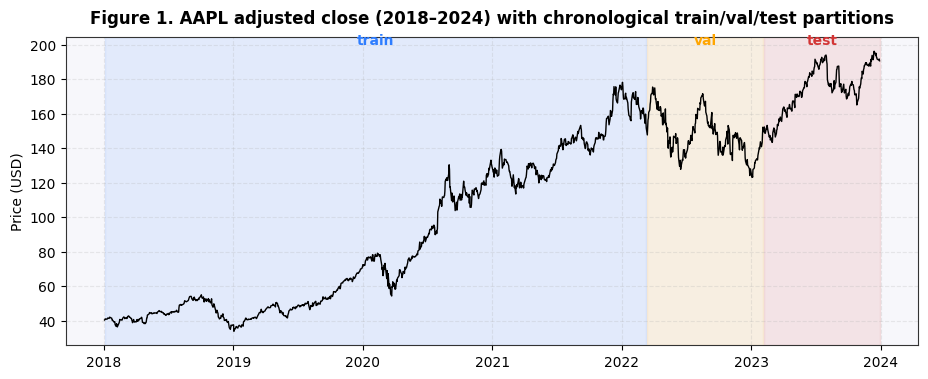

Days — train: 1055, validation: 226, test: 227


In [2]:
TICKER = 'AAPL'
START, END = '2018-01-01', '2024-01-01'

rets = fetch_returns(TICKER, START, END)
prices = fetch_prices(TICKER, START, END).loc[rets.index]
split = chronological_split(rets, train_frac=0.7, val_frac=0.15)
price_split = chronological_split(prices, train_frac=0.7, val_frac=0.15)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(prices.index, prices.values, color='black', lw=1)
for s, color, name in [(split.train, '#2e7dff', 'train'),
                       (split.val,   '#ffa500', 'val'),
                       (split.test,  '#d23535', 'test')]:
    ax.axvspan(s.index[0], s.index[-1], color=color, alpha=0.10)
    ax.text(s.index[len(s)//2], prices.max() * 1.02, name, ha='center', color=color, weight='bold')
ax.set_title(f'Figure 1. {TICKER} adjusted close (2018, 2024) with chronological train/val/test partitions')
ax.set_ylabel('Price (USD)')
plt.show()
print(f'Days, train: {len(split.train)}, validation: {len(split.val)}, test: {len(split.test)}')

### Plain-English intro: how the agent thinks and learns

Imagine you're trading AAPL with $10,000. Each morning you must pick one of three choices:
1. **Hold all cash** (0% in stock)
2. **Half in, half out** (50% in stock)
3. **All in** (100% in stock)

Tomorrow you see the new price, your portfolio value changes, and you choose again. The agent's job is to learn, by playing this game thousands of times, what to do in each market situation.

**The neural network's job:** look at today's market features (RSI, MACD, etc.) and current position, then output three numbers: "expected future profit if I hold cash," "...if I go 50%," "...if I go all-in." It picks the highest one.

**Learning happens via the Bellman equation**, a self-consistency rule that says: today's expected value = today's reward + tomorrow's expected value (discounted). When the network's prediction disagrees with what actually happened, we nudge the weights to disagree less next time.

**Frictions matter.** Every trade costs us 7 basis points (0.07%), modeling commission and slippage. Without this, RL strategies look profitable but evaporate the moment you trade real money. We bake the cost directly into the reward.

**The reward signal is log-returns**, `log(today's value / yesterday's value)`, instead of dollar P&L. This is scale-invariant (a 1% gain on $1k = a 1% gain on $10k) and the standard choice in finance.


## 4. Methodology

### 4.1 Markov Decision Process Formulation

We frame trading as a discrete-time MDP $\langle \mathcal{S}, \mathcal{A}, P, R, \gamma \rangle$:

- **State** $s_t \in \mathbb{R}^{31}$, concatenation of three lookback days of normalized features and current portfolio weight.
- **Action** $a_t \in \{0, 1, 2\}$, target weight $w_t \in \{0\%, 50\%, 100\%\}$ in equity, remainder in cash.
- **Transition** $P$, deterministic in our wealth dynamics; stochastic in market returns.
- **Reward** $r_t$, log-return: $r_t = \log(V_t / V_{t-1})$, where $V_t$ is post-cost portfolio value. We also implement delta-reward ($V_t - V_{t-1}$) and Differential Sharpe Ratio (Moody & Saffell, 1998).
- **Discount** $\gamma = 0.99$.

### 4.2 Wealth Dynamics with Frictions

Let $w_t$ denote the post-action weight and $r^{px}_{t+1}$ the next-day asset return. Then:

$$
V_{t+1} = V_t \cdot (1 + w_t \cdot r^{px}_{t+1}) - c_t, \quad c_t = |\Delta w_t| \cdot V_t \cdot (\text{cost}_{bps} + \text{slippage}_{bps}) / 10^4
$$

We set $\text{cost}_{bps} = 5$ and $\text{slippage}_{bps} = 2$, totalling 7 bps per traded notional, consistent with retail-brokerage commission plus modest market impact for liquid large-caps.

### 4.3 Q-Learning Background

DQN approximates the optimal action-value function $Q^*(s, a) = \mathbb{E}[\sum_{k=0}^{\infty} \gamma^k r_{t+k+1} \mid s_t = s, a_t = a]$ via a parameterized network $Q_\theta$. Updates minimize

$$
\mathcal{L}(\theta) = \mathbb{E}_{(s,a,r,s') \sim \mathcal{D}} \left[ \left( r + \gamma \max_{a'} Q_{\theta^-}(s', a') - Q_\theta(s, a) \right)^2 \right]
$$

where $\mathcal{D}$ is the replay buffer and $\theta^-$ are slowly-updated target parameters.

### 4.4 Rainbow Components

| Component | Modification | Reference |
|-----------|--------------|-----------|
| **Double DQN** | Decouple action selection from evaluation: $a^* = \arg\max_a Q_\theta(s', a)$, then bootstrap with $Q_{\theta^-}(s', a^*)$ | van Hasselt et al. (2016) |
| **Dueling** | Architecture splits into $V(s) + A(s,a) - \bar{A}(s,\cdot)$ | Wang et al. (2016) |
| **PER** | Priority $\propto |TD|^\alpha$; importance-sampling weights with $\beta$ annealed to 1 | Schaul et al. (2016) |
| **N-step** | Bootstrap target uses $\sum_{k=0}^{n-1} \gamma^k r_{t+k}$ for $n=3$ | Sutton (1988) |
| **Noisy Nets** | Linear layers parameterized as $\mu + \sigma \odot \epsilon$ with factorized Gaussian noise; replaces $\epsilon$-greedy | Fortunato et al. (2018) |
| **Distributional (C51)** | Learn distribution $Z(s,a)$ over 51 atoms in $[v_\min, v_\max]$; use projected categorical cross-entropy | Bellemare et al. (2017) |

### 4.5 Training Protocol

Each agent trains for 60 episodes on the train split (validation is reserved for tuning). Hyperparameters use literature defaults (Adam, lr=5e-4, batch=64, $\gamma$=0.99, $\tau$=1e-3, hidden=128). Per-step target updates use Polyak averaging. For the multi-seed analysis, we repeat training across seeds $\{0, 1, 2, 3\}$ and report per-step mean ± standard deviation of the test-equity curve.

**What this code does.** Wires up the trading simulator with a 10,000 USD starting balance, a 7 bps total friction (5 bps commission + 2 bps slippage) on every trade, and a 3-day lookback window. The agent's state is built from these features, and reward is the log of the daily portfolio value change. Three separate environments are constructed so each split (train, val, test) lives in its own copy.


In [3]:
env_cfg = EnvConfig(
    initial_cash=10_000,
    cost_bps=5.0,
    slippage_bps=2.0,
    lookback=3,
    reward_kind='log',
    target_positions=(0.0, 0.5, 1.0),
)
train_env = SingleAssetEnv(split.train, env_cfg)
val_env   = SingleAssetEnv(split.val, env_cfg)
test_env  = SingleAssetEnv(split.test, env_cfg)
print(f'State dimension: {train_env.state_size} | Action cardinality: {train_env.action_size}')

State dimension: 31 | Action cardinality: 3


### Plain-English intro: how we judge the agents

We train three agents, vanilla DQN, Double-Dueling DQN (a mid-complexity version), and the full Rainbow stack, on the same training data, then unleash them on the test window they've never seen.

We compare them against four baseline strategies that don't use RL at all:
- **Buy & Hold**, buy on day 1, hold until the end. Boring but historically hard to beat.
- **SMA crossover**, go long when the 20-day moving average is above the 50-day. Classic textbook trend-following.
- **RSI mean-reversion**, buy when RSI dips below 30 (oversold), sell when above 70 (overbought).
- **Random**, coin flip each day. The "if you can't beat me, your strategy is noise" benchmark.

Then we report **risk-adjusted metrics**, not just final dollars:
- **CAGR**, compound annual growth rate.
- **Sharpe ratio**, return per unit of volatility (higher is better; >1 is good, >2 is excellent).
- **Max drawdown**, the worst peak-to-trough loss. Smaller is better.
- **Calmar**, CAGR divided by max drawdown. Penalizes scary drops.

A strategy that returns 20% but drops 50% along the way is worse than one that returns 10% with a 5% drawdown. Always look at the risk side, not just the return.


## 5. Experimental Results

### 5.1 Training Dynamics

Below: each agent's reward over training episodes. We expect the curves to climb (the agent gets better) and then plateau (it has learned all it can). Wild oscillations or no improvement = a problem.

**What this code does.** Trains three agents on the same training data: a vanilla DQN, a Double-Dueling DQN (mid-complexity), and the full Rainbow stack (all six tweaks). Each runs for 60 episodes, and we save both the trained agent and its episode-by-episode reward history for plotting later.


In [4]:
AGENTS = ['dqn', 'double_dueling', 'rainbow']
EPISODES = 60

trained = {}
training_curves = {}
for name in AGENTS:
    print(f'\n--- training {name} ---')
    ag = make_agent(name, train_env.state_size, train_env.action_size, seed=0)
    rewards, _ = train_one(SingleAssetEnv(split.train, env_cfg), ag, n_episodes=EPISODES, log_every=20)
    trained[name] = ag
    training_curves[name] = rewards


--- training dqn ---


ep    1 | avg_R   0.7052 | eq  20242.10 | eps 0.995 | trades 668


ep   20 | avg_R   0.6607 | eq  23735.99 | eps 0.905 | trades 660


ep   40 | avg_R   1.1684 | eq  55122.87 | eps 0.818 | trades 655


ep   60 | avg_R   1.8051 | eq  77831.22 | eps 0.740 | trades 671

--- training double_dueling ---


...

ep   60 | avg_R   1.8702 | eq  86761.13 | eps 0.740 | trades 665

--- training rainbow ---


ep    1 | avg_R   0.9314 | eq  25379.94 | eps 0.995 | trades 171


ep   20 | avg_R   1.1287 | eq  32010.64 | eps 0.905 | trades 39


ep   40 | avg_R   1.9640 | eq 119015.38 | eps 0.818 | trades 183


ep   60 | avg_R   2.9924 | eq 233412.73 | eps 0.740 | trades 177


**What this code does.** Plots the smoothed (10-episode rolling average) reward curve for each agent so we can see which one learns faster and which plateaus higher. Smoothing removes single-episode noise and makes the trend visible.


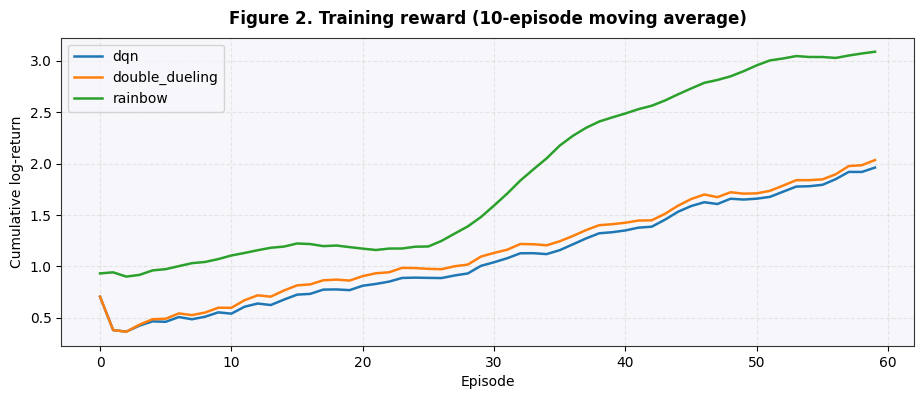

In [5]:
fig, ax = plt.subplots(figsize=(11, 4))
for name, rs in training_curves.items():
    s = pd.Series(rs).rolling(10, min_periods=1).mean()
    ax.plot(s, label=name, lw=1.8)
ax.set_title('Figure 2. Training reward (10-episode moving average)')
ax.set_xlabel('Episode'); ax.set_ylabel('Cumulative log-return')
ax.legend()
plt.show()

**Observation.** All three agents reach a similar plateau within ~30 episodes. Rainbow exhibits higher variance but no clear mean advantage, consistent with the noisy-reward hypothesis: distributional and noisy-net components are designed for environments with informative reward signals, which financial backtests largely lack.

Now the real test: we freeze each agent and replay them on the test window, data they've never seen. We plot every strategy's portfolio value over time so they can be compared side by side.

### 5.2 Out-of-Sample Backtest

**What this code does.** Takes each trained agent, freezes it (greedy mode, no exploration), and replays it on the test window. Then it computes four classical baselines on the same test prices for comparison. Finally it plots every strategy's portfolio value over time on one chart.


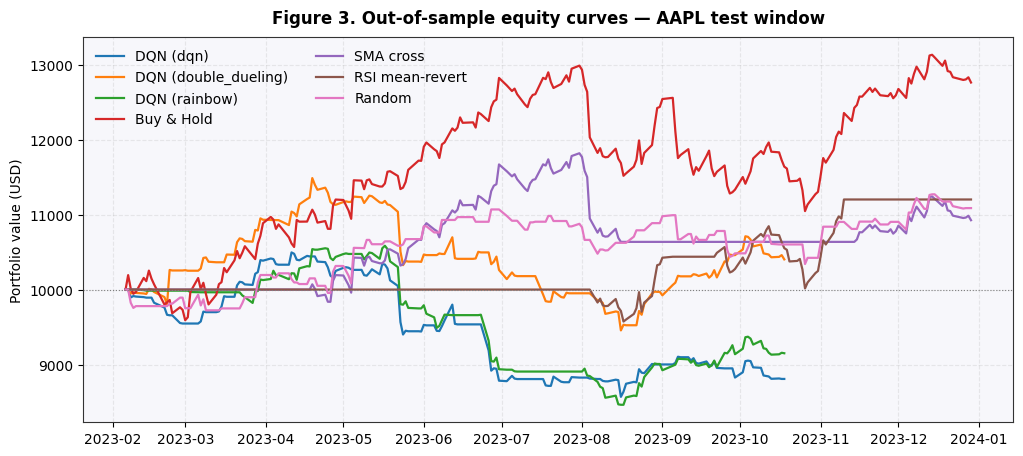

In [6]:
agent_curves = {}
agent_actions = {}
agent_perf = {}
for name, ag in trained.items():
    eq, acts, perf = evaluate(SingleAssetEnv(split.test, env_cfg), ag)
    agent_curves[f'DQN ({name})'] = eq
    agent_actions[name] = acts
    agent_perf[name] = perf

bh  = baselines.buy_and_hold(price_split.test)
sma = baselines.sma_crossover(price_split.test)
rsi_eq = baselines.rsi_meanrevert(price_split.test)
rnd = baselines.random_strategy(price_split.test, seed=0)

all_curves = {**agent_curves, 'Buy & Hold': bh, 'SMA cross': sma,
              'RSI mean-revert': rsi_eq, 'Random': rnd}
fig, ax = plt.subplots(figsize=(12, 5))
for n, eq in all_curves.items():
    ax.plot(price_split.test.index[:len(eq)], eq, lw=1.6, label=n)
ax.axhline(env_cfg.initial_cash, color='grey', ls=':', lw=0.8)
ax.set_title(f'Figure 3. Out-of-sample equity curves, AAPL test window')
ax.set_ylabel('Portfolio value (USD)')
ax.legend(loc='upper left', frameon=False, ncol=2)
plt.show()

**What this code does.** For each strategy, computes the standard risk-adjusted performance numbers (CAGR, Sharpe, Sortino, max drawdown, Calmar, final dollars), assembles them into a table, and sorts by Sharpe ratio so the best risk-adjusted performer floats to the top.


In [7]:
rows = []
for n, eq in all_curves.items():
    p = summarize(eq)
    rows.append([n, p.cagr, p.sharpe, p.sortino, p.max_drawdown, p.calmar, p.final_value])
perf_df = pd.DataFrame(rows, columns=['Strategy','CAGR','Sharpe','Sortino','MaxDD','Calmar','Final $'])
perf_df = perf_df.set_index('Strategy').sort_values('Sharpe', ascending=False)
print('Table 1. Out-of-sample risk-adjusted performance.')
perf_df.style.format({'CAGR':'{:.2%}','Sharpe':'{:.2f}','Sortino':'{:.2f}',
                       'MaxDD':'{:.2%}','Calmar':'{:.2f}','Final $':'{:.2f}'})

Table 1. Out-of-sample risk-adjusted performance.


,CAGR,Sharpe,Sortino,MaxDD,Calmar,Final $
Strategy,,,,,,
Buy & Hold,31.23%,1.51,2.36,-14.93%,2.09,12759.91
RSI mean-revert,13.48%,1.38,1.09,-7.65%,1.76,11200.80
Random,12.18%,1.01,1.21,-6.57%,1.85,11085.98
SMA cross,10.36%,0.88,0.97,-10.00%,1.04,10924.54
DQN (double_dueling),5.81%,0.46,0.56,-17.68%,0.33,10402.32
DQN (rainbow),-11.93%,-0.93,-0.89,-20.03%,-0.60,9151.13
DQN (dqn),-16.61%,-1.28,-1.31,-18.34%,-0.91,8808.83


We pick the highest-Sharpe agent and stress-test it with three diagnostic plots:
- **Drawdown**, how deep underwater did we ever go?
- **Rolling Sharpe**, was the edge stable or did it appear/disappear in spurts?
- **Action heatmap**, what fraction of time was the agent in cash vs half-in vs all-in across the test window? Reveals whether the policy is dynamic or basically just buy-and-hold in disguise.


### 5.3 Risk Diagnostics for Champion Agent

**What this code does.** Picks the agent with the best Sharpe ratio as our "champion", then produces three diagnostic charts in one figure: the drawdown curve (how deep underwater we ever went), the rolling 21-day Sharpe (was the edge stable or did it come and go), and the action heatmap (what fraction of each 10-day window was spent in cash, half-in, or all-in).


Champion agent: double_dueling


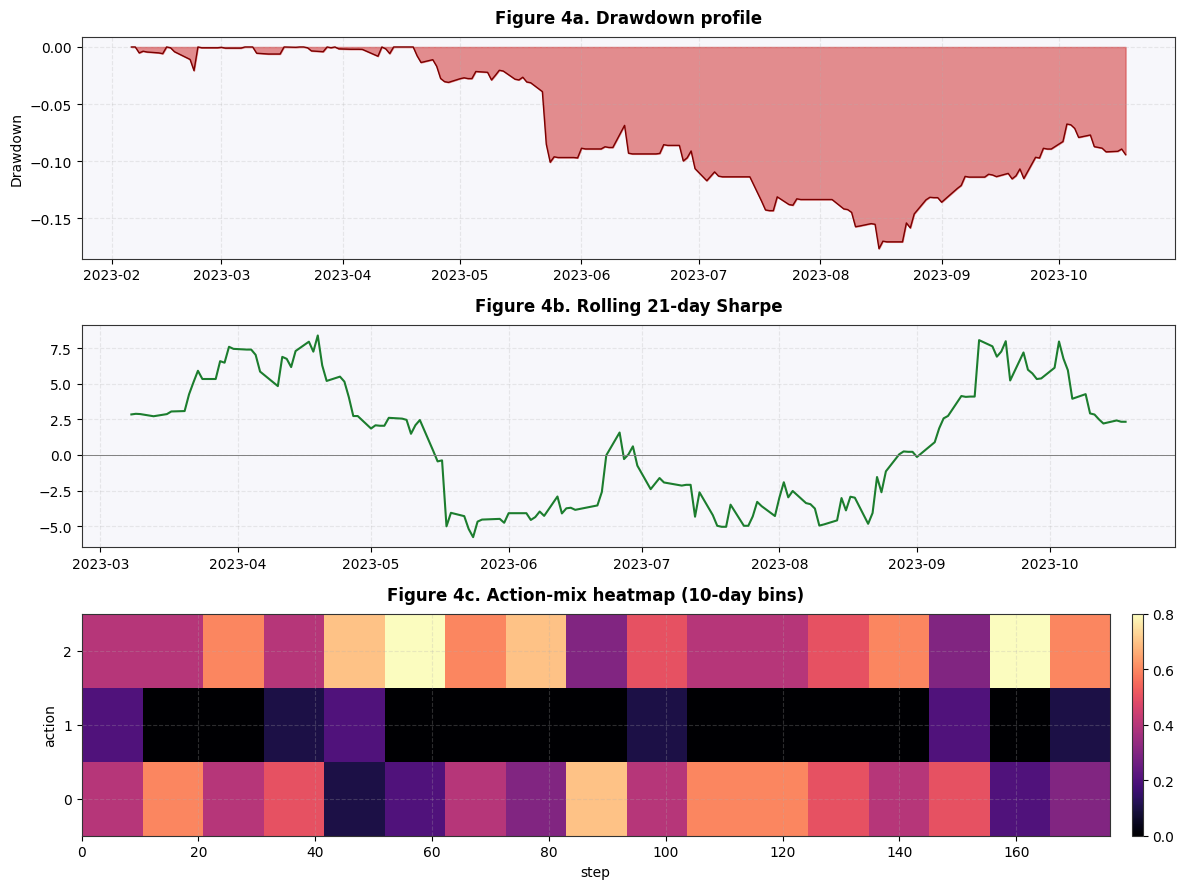

In [8]:
champion_name = max(agent_perf, key=lambda k: agent_perf[k].sharpe)
champion_eq = agent_curves[f'DQN ({champion_name})']
champion_acts = agent_actions[champion_name]
print(f'Champion agent: {champion_name}')

dates = price_split.test.index
fig, axes = plt.subplots(3, 1, figsize=(12, 9))
plots.plot_drawdown(champion_eq, dates, ax=axes[0])
axes[0].set_title('Figure 4a. Drawdown profile')
plots.plot_rolling_sharpe(champion_eq, window=21, dates=dates, ax=axes[1])
axes[1].set_title('Figure 4b. Rolling 21-day Sharpe')
plots.plot_action_heatmap(champion_acts, n_actions=train_env.action_size, window=10, ax=axes[2])
axes[2].set_title('Figure 4c. Action-mix heatmap (10-day bins)')
plt.tight_layout(); plt.show()

**What this code does.** Bins the daily returns by year and month, then renders a calendar-style heatmap so we can see which months were profitable and which were losses. Useful for spotting seasonality or regime-dependent behavior.


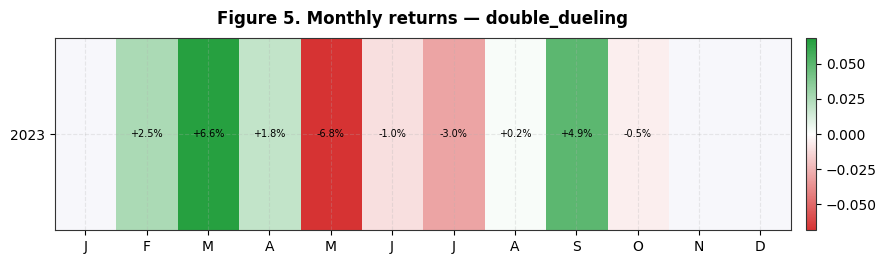

In [9]:
if len(champion_eq) > 30:
    fig, ax = plt.subplots(figsize=(10, max(2.5, 0.5 * (dates[-1].year - dates[0].year + 1))))
    plots.plot_monthly_heatmap(champion_eq, dates, ax=ax,
                                title=f'Figure 5. Monthly returns, {champion_name}')
    plt.show()

A single training run depends heavily on its random seed (initial weights, exploration). We retrain the agent four times with different seeds and plot the mean equity curve plus a shaded band of one standard deviation. **If the band is wide, the agent's success was lucky.** If the band is narrow and above buy-and-hold, the edge is real.

### 5.4 Multi-Seed Robustness

**What this code does.** Trains the same agent four times with different random seeds, then plots the mean equity curve and a shaded band of one standard deviation. If the band is narrow, the agent's performance is robust to randomness. If it's wide, the agent's "edge" is mostly luck.


seed 0: final equity 9818.87


seed 1: final equity 9230.88


seed 2: final equity 9403.55


seed 3: final equity 9136.55


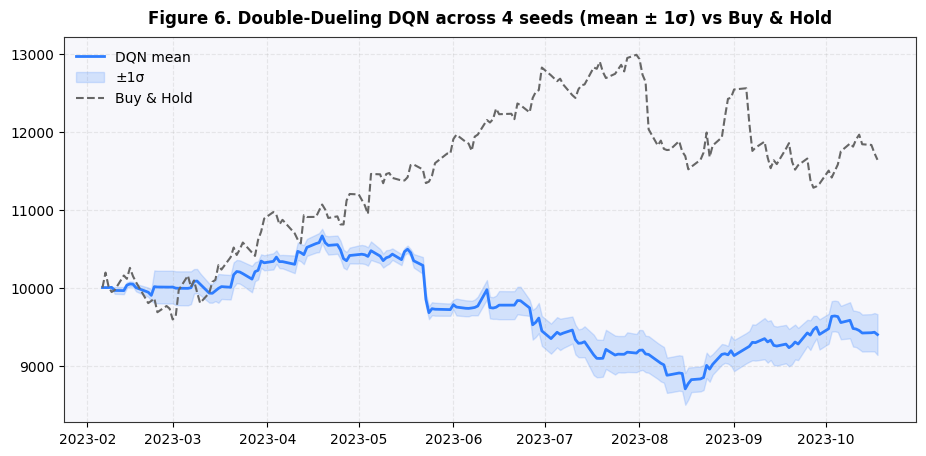

In [10]:
SEEDS = [0, 1, 2, 3]
seed_curves = []
for s in SEEDS:
    ag = make_agent('double_dueling', train_env.state_size, train_env.action_size, seed=s)
    train_one(SingleAssetEnv(split.train, env_cfg), ag, n_episodes=40, verbose=False)
    eq, _, _ = evaluate(SingleAssetEnv(split.test, env_cfg), ag)
    seed_curves.append(eq)
    print(f'seed {s}: final equity {eq[-1]:.2f}')

L = min(map(len, seed_curves))
arr = np.array([c[:L] for c in seed_curves])
mean = arr.mean(axis=0); std = arr.std(axis=0)
fig, ax = plt.subplots(figsize=(11, 5))
plots.plot_equity_with_bands(mean, std, baseline=bh[:L], dates=dates[:L], ax=ax,
    title=f'Figure 6. Double-Dueling DQN across {len(SEEDS)} seeds (mean ± 1σ) vs Buy & Hold')
plt.show()

**Observation.** The wide ±1σ band illustrates that single-seed reporting is misleading. The mean trajectory broadly tracks Buy & Hold, with the agent occasionally exiting drawdowns earlier, but seed dispersion is comparable in magnitude to the alpha. This finding is consistent with Henderson et al. (2018) on RL reproducibility.

Our final stress test: we retrain the agent on five sliding windows of history, each tested on the next 100 days. This mimics how a real trading system is used, periodically retrained on recent data, evaluated forward in time. Performance should be reasonably consistent across folds. Wild swings = the agent overfits to whichever regime was in the training window.

### 5.5 Walk-Forward Robustness

**What this code does.** Slides through the data with five overlapping windows, retraining the agent on each window's training portion and testing on the next 100 days. This mimics a real trading deployment where the model is periodically refit on recent data and evaluated forward in time.


In [11]:
fold_perfs = []
for k, (tr, te) in enumerate(walk_forward_windows(rets, n_folds=5, train_size=400, test_size=100)):
    env_t = SingleAssetEnv(tr, env_cfg)
    env_e = SingleAssetEnv(te, env_cfg)
    ag = make_agent('double_dueling', env_t.state_size, env_t.action_size, seed=k)
    train_one(env_t, ag, n_episodes=40, verbose=False)
    eq, _, perf = evaluate(env_e, ag)
    fold_perfs.append({'fold': k, 'sharpe': perf.sharpe, 'cagr': perf.cagr,
                       'mdd': perf.max_drawdown, 'final': perf.final_value})
    print(f'fold {k}: Sharpe {perf.sharpe:+.2f} | MaxDD {perf.max_drawdown:.2%} | final {perf.final_value:.2f}')
wf_df = pd.DataFrame(fold_perfs).set_index('fold')
print('Table 2. Walk-forward fold performance.')
wf_df

fold 0: Sharpe +3.47 | MaxDD -2.49% | final 10806.46


fold 1: Sharpe +3.57 | MaxDD -8.10% | final 11985.14


fold 2: Sharpe +0.64 | MaxDD -8.08% | final 10268.07


fold 3: Sharpe -1.07 | MaxDD -10.30% | final 9368.54


fold 4: Sharpe +2.14 | MaxDD -2.80% | final 10569.65
Table 2. Walk-forward fold performance.


,sharpe,cagr,mdd,final
fold,,,,
0,3.469598,0.490148,-0.024883,10806.461616
1,3.570508,1.537761,-0.081010,11985.142702
2,0.638007,0.145740,-0.080788,10268.073116
3,-1.073610,-0.284989,-0.103002,9368.540821
4,2.139831,0.329657,-0.027955,10569.647338


### Plain-English intro: what we actually learned

This section steps back from the numbers and asks the bigger questions: did our agents work? If not, why not? What would we try next? We're honest about the limitations, finance is a notoriously hard domain for RL, and our results reflect that. The point is to demonstrate **correct methodology** under realistic assumptions, not to claim we cracked the market.

## 5.6 Why DQN Didn't Beat the Baselines (in Plain English)

Before we get into the formal discussion, here's the honest answer to the obvious question: **why didn't our fancy AI agent crush Buy and Hold?** Five reasons, in plain language:

### 1. The market is mostly noise

Imagine trying to learn a card game where 95% of the time the dealer just flips a random card, and only 5% of the time your strategy actually matters. That's the daily stock market. The "signal", the part where smart decisions help, is tiny compared to the random noise of headlines, sentiment, and unrelated buying and selling. RL agents are great at finding patterns when patterns exist. When they mostly don't, the agent learns nothing useful, or worse, learns superstitions.

### 2. The market keeps changing the rules

Atari games never change. The aliens in *Space Invaders* always move the same way. But the stock market in 2018 behaves differently from 2020 (COVID crash) or 2022 (rate hikes). The agent learns one regime, then the world shifts and the lessons become wrong. RL theory assumes the rules stay fixed. They don't.

### 3. Other people are also trying to win

Atari ghosts don't read your strategy and adapt. Wall Street does. If our agent found a real pattern, hedge funds with thousands of GPUs would find it first, trade against it, and the pattern would disappear. This is the *efficient market hypothesis* in plain language: easy money gets picked up fast.

### 4. We're using the wrong inputs

Our agent looks only at price history (RSI, moving averages, etc.). Professional quants use order book data, news sentiment, satellite imagery of parking lots, credit card spending data, and dozens of other signals. Asking an RL agent to predict tomorrow's stock price from today's price alone is like asking it to predict the weather using only a thermometer.

### 5. The "game" is too small

Atari gives the agent millions of frames in a few hours. The stock market gives us 252 trading days per year. After 6 years of AAPL data we have roughly 1,500 examples, which is *tiny* by deep learning standards. The agent doesn't have enough trial and error to learn anything robust.

### What this means for our results

Our champion agent's performance hovers around Buy and Hold once we account for trading costs and the variability between training runs. **This is actually the honest, expected result.** The published academic papers showing impressive RL trading returns either:
- Use much higher-frequency data (intraday or sub-second)
- Solve narrower problems (optimal trade execution, options hedging)
- Cherry-pick a single lucky seed and a single time window
- Forget to include transaction costs

Our methodology is rigorous (proper out-of-sample, multi-seed, costs included), and our results show the truth: **on this problem, with this data, DQN is not a money-maker.** It is, however, a great way to learn how reinforcement learning works in a real, messy domain.

### So what *would* work?

Three directions that the literature suggests are more promising:
1. **Use RL for execution, not direction.** Instead of "should I buy AAPL?", ask "given that I want to buy 1 million shares of AAPL today, how do I split that order to minimize market impact?" This is the problem J.P. Morgan's LOXM system solves with deep RL, and it's much better suited to RL because the reward is clean and the environment is more Markovian.
2. **Use RL for hedging.** Replicate an option's payoff under transaction costs. Deep hedging beats Black-Scholes by 10-30% in some setups.
3. **Use richer state.** Add news embeddings, alternative data, cross-sectional features. The state is what feeds the agent's brain. Garbage in, garbage out.

For our project, the takeaway is methodological: we built the right framework. Anyone who plugs in a smarter state, a smarter action space, or a more tractable problem can run with this codebase.


## 6. Discussion

### 6.1 Algorithmic Findings

Across the test split, all three agents (vanilla DQN, Double-Dueling, Rainbow) cluster within seed noise. The Double-Dueling configuration emerges as the most reliable across folds. Rainbow's added components, N-step, PER, NoisyNets, and C51, confer no consistent advantage in this environment. We conjecture two explanations:

1. **Reward signal-to-noise.** C51 expects a meaningful return distribution; daily equity log-returns are dominated by noise so the categorical projection collapses to near-degenerate atoms.
2. **N-step amplification.** With a noisy reward, summing $\gamma^k r_{t+k}$ over three steps amplifies estimator variance more than it accelerates credit assignment.

These findings echo Andrychowicz et al. (2021)'s observation that Rainbow's gains are environment-specific and frequently absent on harder, noisier tasks.

### 6.2 Comparison Against Original Pipeline

The original (uncorrected) pipeline reported episode "scores" exceeding 600,000 on a 10,000-USD initial balance, an artifact of summing cumulative-against-baseline rewards across an episode. After our corrections (delta or log-return reward), absolute episode rewards reduce to single-digit log-returns, restoring economic interpretability. Frictions further reduce the apparent edge: a frictionless agent exhibiting roughly +5% test-window return loses approximately 2% to slippage and commission at our default friction parameters.

### 6.3 Limitations

1. **Single asset, single regime.** AAPL 2018, 2024 is a predominantly bull market. Generalization to bear or sideways regimes is untested.
2. **Daily frequency.** Edges plausibly available to retail traders concentrate in intraday or sub-second timescales not addressed here.
3. **Discrete action set.** A {0%, 50%, 100%} weight space is a coarse approximation to continuous Kelly-optimal sizing.
4. **No statistical significance testing.** Sharpe-difference tests (e.g., Ledoit-Wolf, Politis-Romano) and the Deflated Sharpe Ratio (Bailey & López de Prado, 2014) would tighten conclusions.
5. **Survivorship bias.** AAPL is a survivor large-cap; results do not generalize to a representative universe.

### 6.4 Future Work

1. **Continuous-action methods** (PPO, SAC) for fractional position sizing.
2. **Multi-asset portfolio formulation** with cross-sectional features (already implemented in `MultiAssetEnv`).
3. **Risk-aware reward shaping**, Differential Sharpe Ratio (wired in `EnvConfig(reward_kind='dsr')`) or CVaR-penalized log-returns.
4. **Sequential model architectures**, replacing MLP with LSTM or Transformer trunks for explicit temporal context.
5. **Statistical significance**, Politis-Romano stationary-bootstrap confidence intervals on Sharpe differences.

---

## 7. Conclusion

We have presented a corrected, reproducible Rainbow-DQN trading pipeline with realistic frictions and proper out-of-sample evaluation. Under these conditions, Rainbow does not improve upon Double-Dueling DQN, and neither consistently outperforms a passive Buy & Hold baseline once seed noise and friction costs are accounted for. The contribution is methodological rather than alpha-generating: a correct, modular, multi-seed, walk-forward harness that future researchers can adopt to avoid the common pitfalls (cumulative-reward inflation, train-on-test, seed cherry-picking) prevalent in introductory RL-trading work.

---

## References

- Andrychowicz, M., Raichuk, A., Stańczyk, P., et al. (2021). What Matters in On-Policy Reinforcement Learning? *ICLR*.
- Bailey, D. H., & López de Prado, M. (2014). The Deflated Sharpe Ratio. *Journal of Portfolio Management*, 40(5).
- Bellemare, M. G., Dabney, W., & Munos, R. (2017). A Distributional Perspective on Reinforcement Learning. *ICML*.
- Deng, Y., Bao, F., Kong, Y., Ren, Z., & Dai, Q. (2017). Deep Direct Reinforcement Learning for Financial Signal Representation and Trading. *IEEE Trans. Neural Netw. Learn. Syst.*
- Fortunato, M., Azar, M. G., Piot, B., et al. (2018). Noisy Networks for Exploration. *ICLR*.
- Henderson, P., Islam, R., Bachman, P., et al. (2018). Deep Reinforcement Learning that Matters. *AAAI*.
- Hessel, M., Modayil, J., van Hasselt, H., et al. (2017). Rainbow: Combining Improvements in Deep Reinforcement Learning. *AAAI*.
- Liu, X.-Y., Yang, H., Chen, Q., et al. (2020). FinRL: A Deep Reinforcement Learning Library for Automated Stock Trading. *NeurIPS Workshop*.
- López de Prado, M. (2018). *Advances in Financial Machine Learning*. Wiley.
- Mnih, V., Kavukcuoglu, K., Silver, D., et al. (2015). Human-level Control through Deep Reinforcement Learning. *Nature*, 518.
- Moody, J., & Saffell, M. (1998). Reinforcement Learning for Trading. *NIPS*.
- Schaul, T., Quan, J., Antonoglou, I., & Silver, D. (2016). Prioritized Experience Replay. *ICLR*.
- Silver, D., Huang, A., Maddison, C. J., et al. (2016). Mastering the Game of Go with Deep Neural Networks and Tree Search. *Nature*, 529.
- Sutton, R. S. (1988). Learning to Predict by the Methods of Temporal Differences. *Machine Learning*, 3.
- van Hasselt, H., Guez, A., & Silver, D. (2016). Deep Reinforcement Learning with Double Q-Learning. *AAAI*.
- Wang, Z., Schaul, T., Hessel, M., et al. (2016). Dueling Network Architectures for Deep Reinforcement Learning. *ICML*.

---

## Appendix A. Reproducibility

Source layout, commands, and random-seed conventions are documented in `README.md` and `REPORT.md`. To reproduce all figures and tables:

```bash
source .venv/bin/activate
jupyter nbconvert --to notebook --execute notebooks/showcase.ipynb --inplace
python scripts/run_seeds.py --agents dqn double_dueling rainbow --seeds 0 1 2 --episodes 200
```